## Lab 7 ML
#### Name: Ishika Sahare

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)


In [78]:
df=pd.read_csv("Raisin_Dataset.csv")

In [79]:
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [80]:
df.tail()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
895,83248,430.077308,247.838695,0.817263,85839,0.668793,1129.072,Besni
896,87350,440.735698,259.293149,0.808629,90899,0.636476,1214.252,Besni
897,99657,431.706981,298.837323,0.721684,106264,0.741099,1292.828,Besni
898,93523,476.344094,254.176054,0.845739,97653,0.658798,1258.548,Besni
899,85609,512.081774,215.271976,0.907345,89197,0.632020,1272.862,Besni


In [81]:
df.shape

(900, 8)

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLength  900 non-null    float64
 3   Eccentricity     900 non-null    float64
 4   ConvexArea       900 non-null    int64  
 5   Extent           900 non-null    float64
 6   Perimeter        900 non-null    float64
 7   Class            900 non-null    object 
dtypes: float64(5), int64(2), object(1)
memory usage: 56.4+ KB


In [83]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,900.0,87804.127778,39002.111390,25387.000000,59348.000000,78902.000000,105028.250000,235047.000000
MajorAxisLength,900.0,430.929950,116.035121,225.629541,345.442898,407.803951,494.187014,997.291941
MinorAxisLength,900.0,254.488133,49.988902,143.710872,219.111126,247.848409,279.888575,492.275279
Eccentricity,900.0,0.781542,0.090318,0.348730,0.741766,0.798846,0.842571,0.962124
ConvexArea,900.0,91186.090000,40769.290132,26139.000000,61513.250000,81651.000000,108375.750000,278217.000000
Extent,900.0,0.699508,0.053468,0.379856,0.670869,0.707367,0.734991,0.835455
Perimeter,900.0,1165.906636,273.764315,619.074000,966.410750,1119.509000,1308.389750,2697.753000


In [84]:
df.duplicated().sum()

0

In [85]:
df.isnull().sum()

Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64

In [86]:
df["Class"].unique()

array(['Kecimen', 'Besni'], dtype=object)

In [87]:
df["Class"].value_counts()

Class
Kecimen    450
Besni      450
Name: count, dtype: int64

# Bar Plot

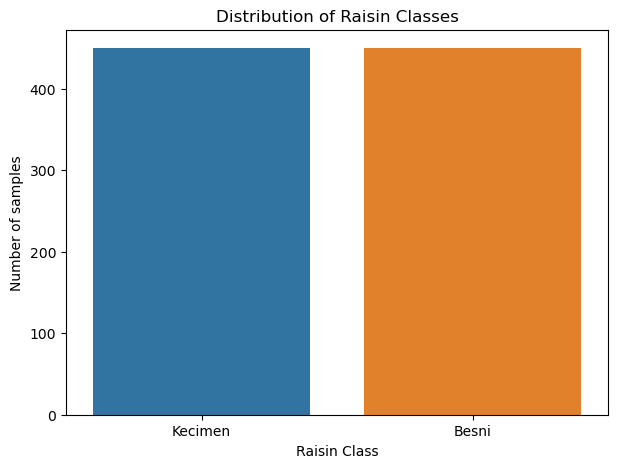

In [88]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,x="Class")

plt.title("Distribution of Raisin Classes")
plt.xlabel("Raisin Class")
plt.ylabel("Number of samples")
plt.show()

# Pie-Chart

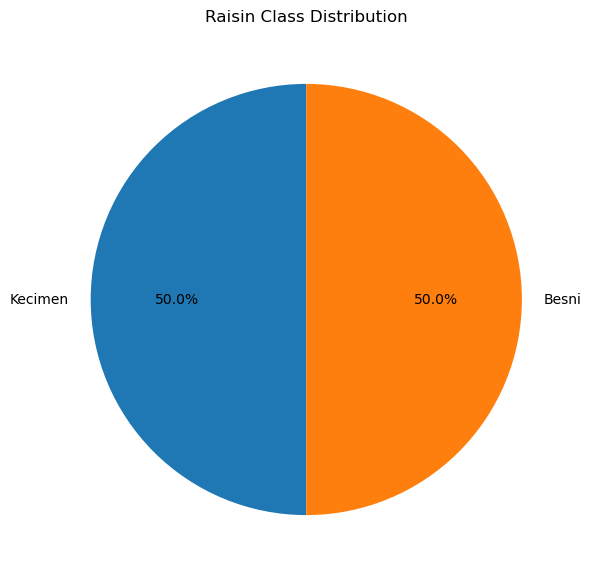

In [89]:
class_counts=df["Class"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(class_counts, labels=class_counts.index, autopct="%1.1f%%", startangle=90)

plt.title("Raisin Class Distribution")

plt.show()

In [90]:
numerical_features = df.select_dtypes(include=np.number).columns

print("Numerical Features")
print(numerical_features.tolist())

Numerical Features
['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']


# Histogram

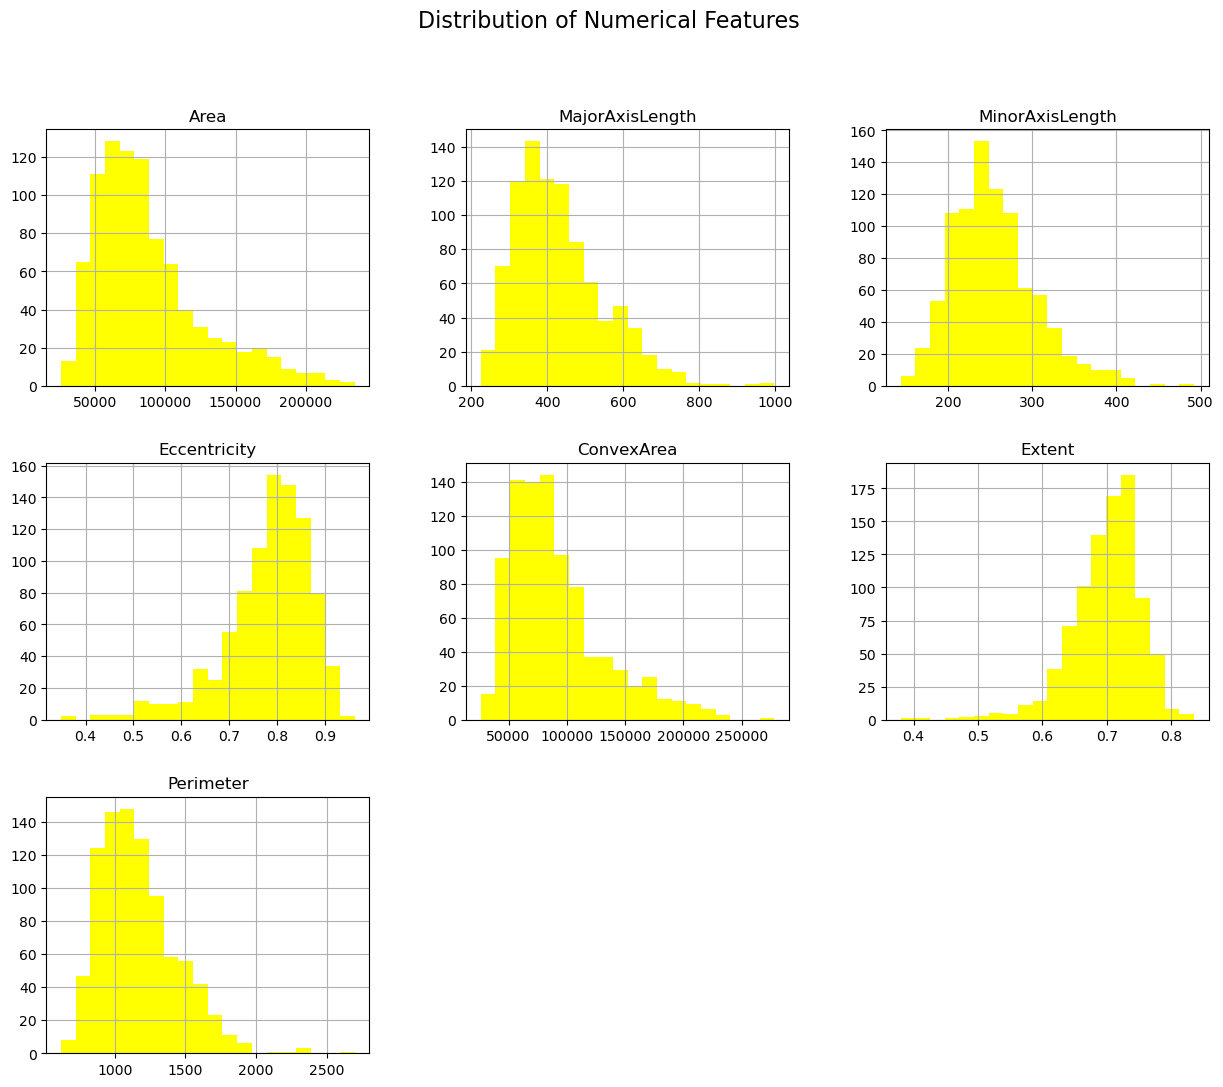

In [91]:
df[numerical_features].hist(figsize=(15, 12), bins=20, color='yellow')
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()


# Box plots

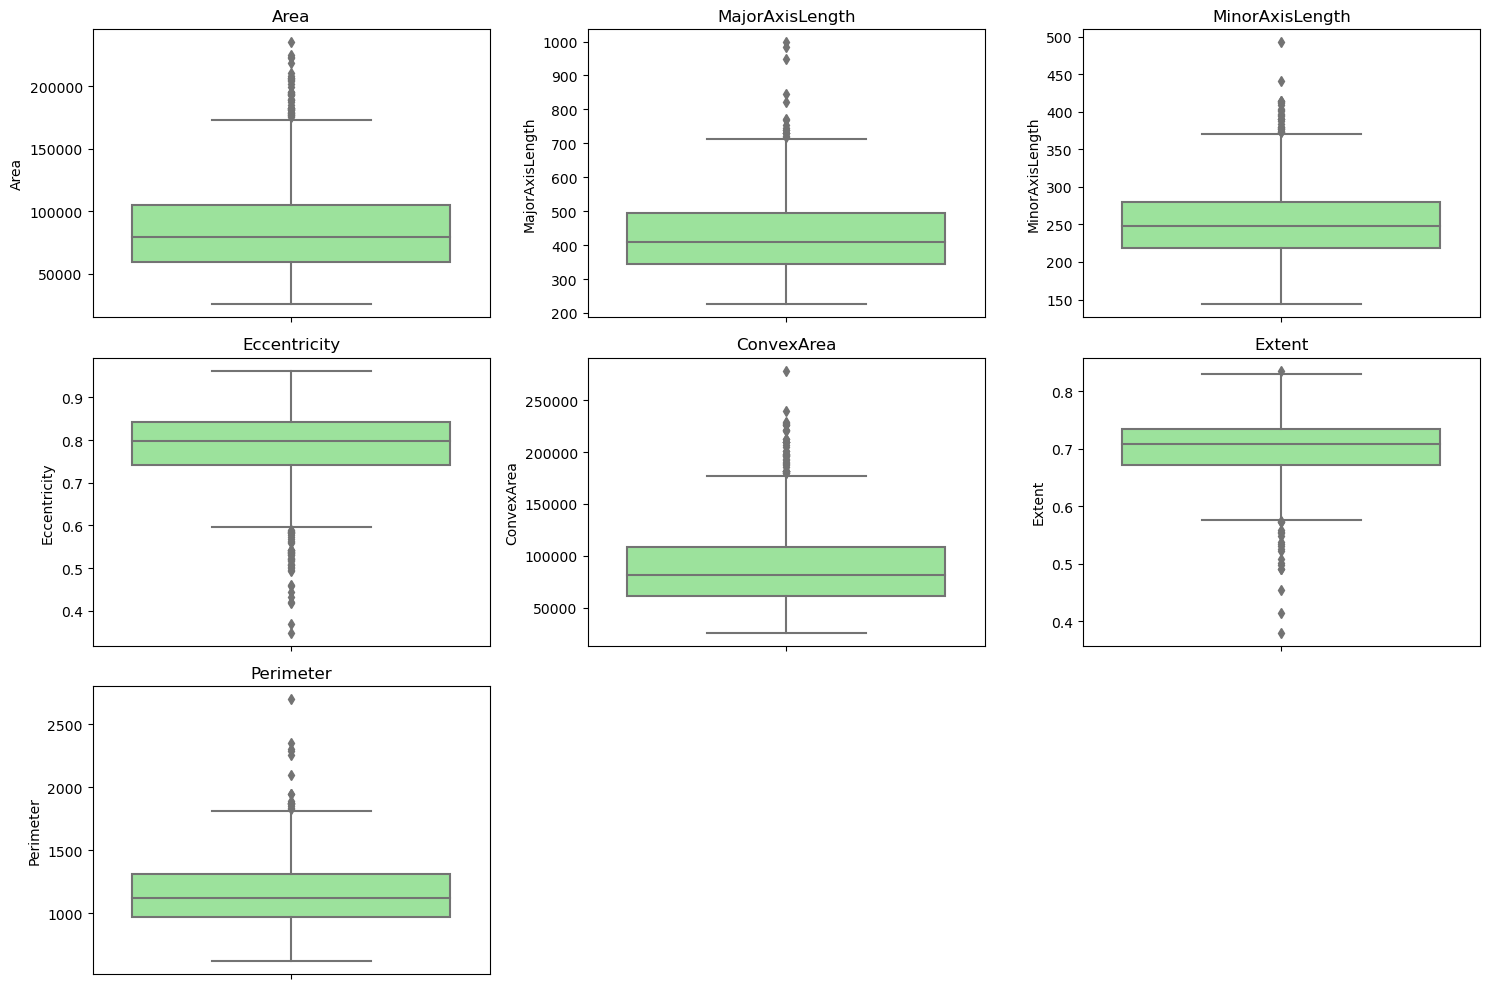

In [92]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[column], color='lightgreen')
    plt.title(column)
    
plt.tight_layout()
plt.show()


# Histogram with kde

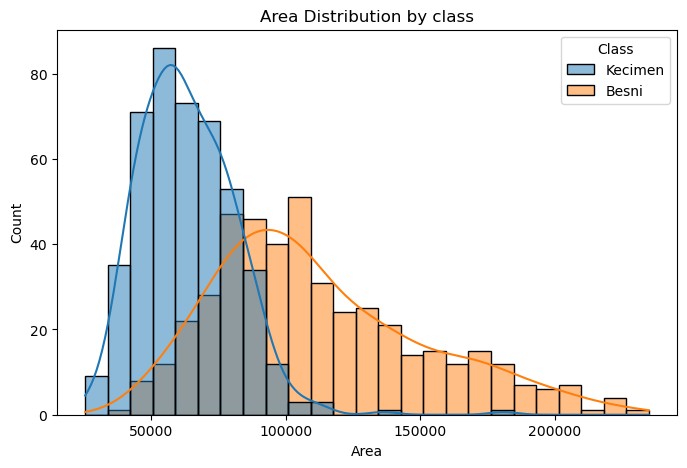

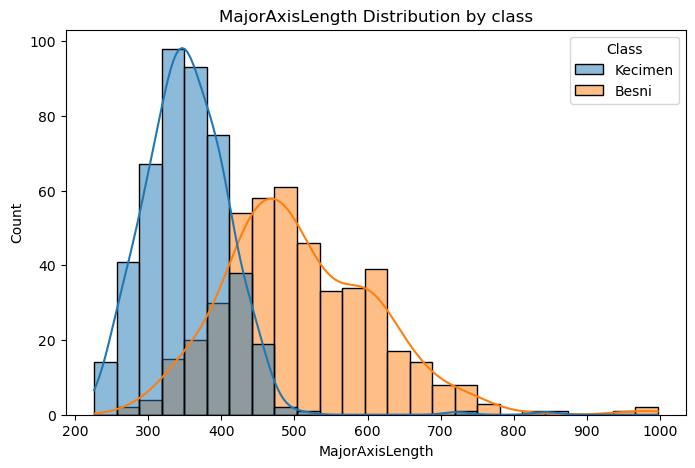

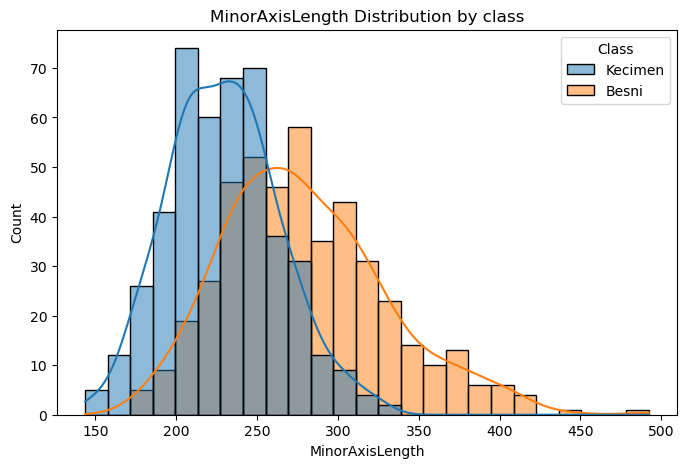

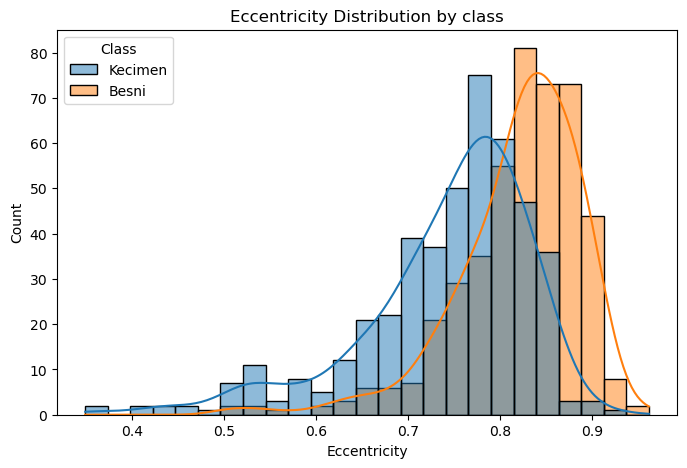

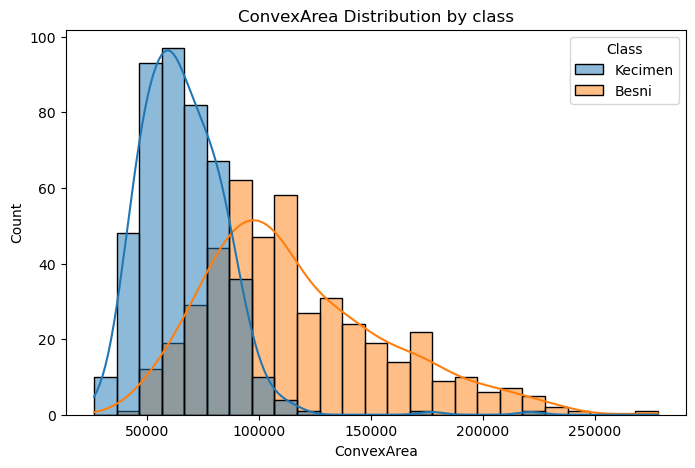

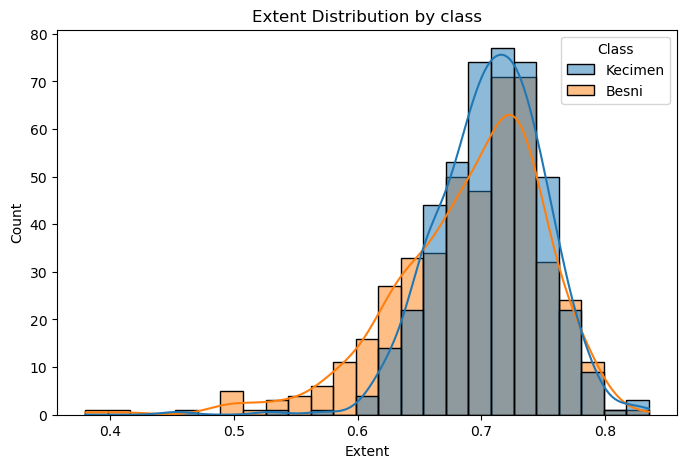

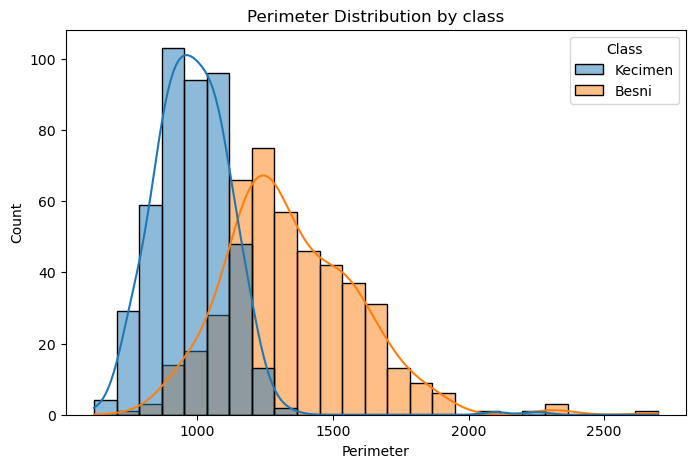

In [93]:
for column in numerical_features:
    plt.figure(figsize=(8,5))
    sns.histplot(data=df,x=column,hue="Class",kde=True,bins=25)
    plt.title(f"{column} Distribution by class")
    plt.show()
    

# Correlation Matrix

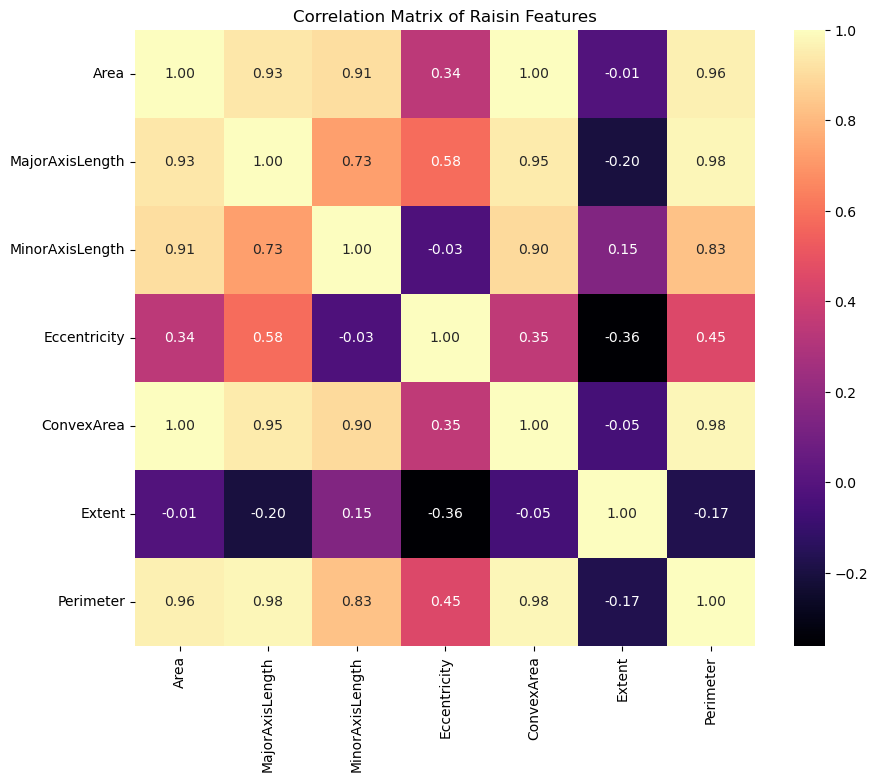

In [94]:
correlation_matrix= df[numerical_features].corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True,fmt=".2f",cmap="magma")
plt.title("Correlation Matrix of Raisin Features")
plt.show()

# Scatter PLot

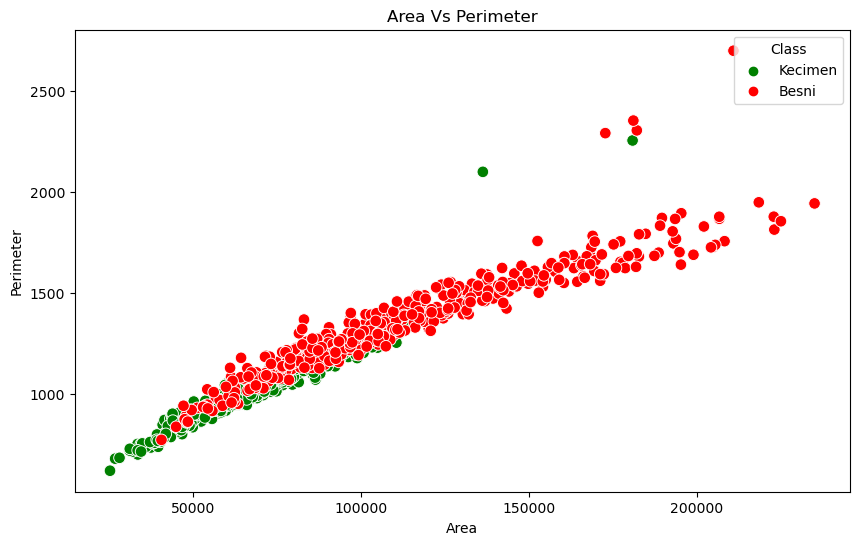

In [95]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="Area",y="Perimeter",palette={'Kecimen':'Green', 'Besni' : 'Red'},
               hue="Class",
               s=70
            )
plt.title("Area Vs Perimeter")
plt.show()

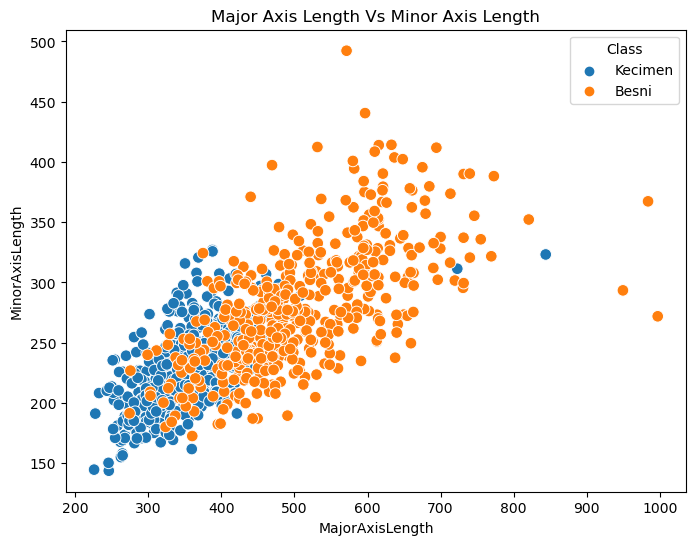

In [96]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,x="MajorAxisLength",y="MinorAxisLength",hue="Class", s=70)
plt.title("Major Axis Length Vs Minor Axis Length")
plt.show()

In [97]:
label_encoder=LabelEncoder()
df["Class_encoded"] =label_encoder.fit_transform(df["Class"])
print(df[["Class","Class_encoded"]].head(10))

     Class  Class_encoded
0  Kecimen              1
1  Kecimen              1
2  Kecimen              1
3  Kecimen              1
4  Kecimen              1
5  Kecimen              1
6  Kecimen              1
7  Kecimen              1
8  Kecimen              1
9  Kecimen              1


In [98]:
print("Class mapping")
for index , class_name in enumerate(label_encoder.classes_):
    print(index,"=",class_name)

Class mapping
0 = Besni
1 = Kecimen


In [99]:
X = df.drop(columns=["Class", "Class_encoded"])
y = df["Class_encoded"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (900, 7)
y shape: (900,)


In [100]:
X_train, X_test,y_train,y_test=train_test_split(X,y,test_size=0.02,random_state=42,stratify=y)
print("Training samples: ",X_train.shape[0])
print("Testing samples: ",X_test.shape[0])

Training samples:  882
Testing samples:  18


In [101]:
GaussianNB()

GaussianNB()

In [102]:
gnb = GaussianNB()
gnb.fit(X_train,y_train)

GaussianNB()

In [103]:
y_pred = gnb.predict(X_test)
print("Predicted labels:")
print(y_pred)

Predicted labels:
[0 1 0 1 1 1 0 1 1 0 1 1 0 1 1 1 1 0]


In [104]:
comparison = pd.DataFrame({"Actual":y_test.values, "Prediction": y_pred})
print(comparison.head(5))

   Actual  Prediction
0       0           0
1       1           1
2       0           0
3       1           1
4       1           1


In [105]:
comparison["Actual_Class"] = label_encoder.inverse_transform(comparison["Actual"])
comparison["Predicted_Class"] = label_encoder.inverse_transform(comparison["Prediction"])
comparison.head()

,Actual,Prediction,Actual_Class,Predicted_Class
0,0,0,Besni,Besni
1,1,1,Kecimen,Kecimen
2,0,0,Besni,Besni
3,1,1,Kecimen,Kecimen
4,1,1,Kecimen,Kecimen


In [106]:
accuracy =accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print("Accuracy(%):",accuracy*100)

Accuracy: 0.7222222222222222
Accuracy(%): 72.22222222222221


In [107]:
precision= precision_score(y_test,y_pred)
print("Precision: ",precision)

Precision:  0.6666666666666666


In [108]:
recall = recall_score(y_test,y_pred)
print("Recall:",recall)

Recall: 0.8888888888888888


In [109]:
f1 = f1_score(y_test, y_pred)
print("F1 Score: ",f1)

F1 Score:  0.761904761904762


In [110]:
print("======================")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision: .4f}")
print(f"Recall: {recall: .4f}")
print(f"F1- Score: {f1: .4f}")

Accuracy: 0.7222
Precision:  0.6667
Recall:  0.8889
F1- Score:  0.7619


In [111]:
cm= confusion_matrix(y_test,y_pred)
print("Confusion Matrix")
print(cm)

Confusion Matrix
[[5 4]
 [1 8]]


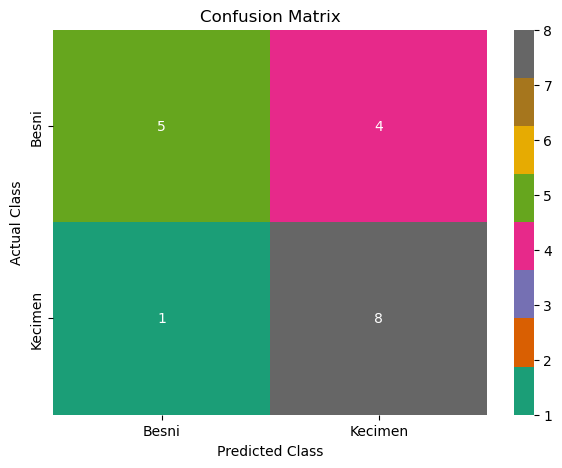

In [112]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Dark2", 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()


In [113]:
from sklearn.metrics import accuracy_score

y_train_pred = gnb.predict(X_train) 
y_test_pred = gnb.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:",train_accuracy)
print("Test Accuracy: ",test_accuracy)

Training Accuracy: 0.8344671201814059
Test Accuracy:  0.7222222222222222


In [114]:
GaussianNB(priors=None)

GaussianNB()

# Hyperparameters

In [115]:
GaussianNB(var_smoothing=1e-9)

GaussianNB()

In [116]:
print(gnb.get_params())

{'priors': None, 'var_smoothing': 1e-09}


In [117]:
smoothing_values = [1e-12, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
results = []

for value in smoothing_values:
    model = GaussianNB(var_smoothing=value)
    
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    
    acc = accuracy_score(y_test, prediction)
    prec = precision_score(y_test, prediction, average='binary') # Adjust average if multiclass
    rec = recall_score(y_test, prediction, average='binary')
    f1_value = f1_score(y_test, prediction, average='binary')
    
    results.append([value, acc, prec, rec, f1_value])


In [118]:
results_df = pd.DataFrame(
    results,
    columns=["var_smoothing", "Accuracy", "Precision", "Recall", "F1_Score"]
)
results_df


,var_smoothing,Accuracy,Precision,Recall,F1_Score
0,1.000000e-12,0.722222,0.666667,0.888889,0.761905
1,1.000000e-10,0.722222,0.666667,0.888889,0.761905
2,1.000000e-09,0.722222,0.666667,0.888889,0.761905
3,1.000000e-08,0.722222,0.666667,0.888889,0.761905
4,1.000000e-07,0.722222,0.666667,0.888889,0.761905
5,1.000000e-06,0.722222,0.666667,0.888889,0.761905
6,1.000000e-05,0.666667,0.615385,0.888889,0.727273
7,1.000000e-04,0.611111,0.571429,0.888889,0.695652
8,1.000000e-03,0.611111,0.571429,0.888889,0.695652
9,1.000000e-02,0.611111,0.571429,0.888889,0.695652


In [119]:
import pandas as pd

area = float(input("Enter Area: "))
major_axis = float(input("Enter Major Axis Length: "))
minor_axis = float(input("Enter Minor Axis Length: "))
eccentricity = float(input("Enter Eccentricity: "))
convex_area = float(input("Enter Convex Area: "))
extent = float(input("Enter Extent: "))
perimeter = float(input("Enter Perimeter: "))

new_sample = pd.DataFrame({
    "Area": [area],
    "MajorAxisLength": [major_axis],
    "MinorAxisLength": [minor_axis],
    "Eccentricity": [eccentricity],
    "ConvexArea": [convex_area],
    "Extent": [extent],
    "Perimeter": [perimeter]
})

prediction = gnb.predict(new_sample.values)
predicted_class = label_encoder.inverse_transform(prediction)

print("\nPredicted Raisin Class:", predicted_class[0])

Enter Area: 15436
Enter Major Axis Length: 15646
Enter Minor Axis Length: 13546
Enter Eccentricity: 13546
Enter Convex Area: 513
Enter Extent: 546
Enter Perimeter: 51

Predicted Raisin Class: Kecimen


C:\Users\cse\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [120]:
print(gnb.feature_names_in_)

['Area' 'MajorAxisLength' 'MinorAxisLength' 'Eccentricity' 'ConvexArea'
 'Extent' 'Perimeter']
